In [2]:
from google.colab import files
from google.colab import drive
import shutil
import os
import pandas as pd

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Set up the specific directory
drive_folder = '/content/drive/MyDrive/Statsbomb_Data/'
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)
    print(f"Created folder: {drive_folder}")

# 3. Open the file picker for the cleaned dataset
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

    # Destination name specifically for the encoded data
    destination = os.path.join(drive_folder, 'shots_cleaned_encoded.csv')

    # Move the file to Drive
    shutil.move(filename, destination)
    print(f"✅ Success! Moved {filename} to {destination}")

# 4. Load it into your DataFrame
df = pd.read_csv(destination)
print(f"✅ DataFrame loaded with {len(df)} rows and {len(df.columns)} columns.")

Mounted at /content/drive


Saving shots_cleaned_encoded.csv to shots_cleaned_encoded.csv
User uploaded file "shots_cleaned_encoded.csv" with length 8859573 bytes
✅ Success! Moved shots_cleaned_encoded.csv to /content/drive/MyDrive/Statsbomb_Data/shots_cleaned_encoded.csv
✅ DataFrame loaded with 64898 rows and 38 columns.


In [3]:
df.columns

Index(['x', 'y', 'is_goal', 'shot_first_time', 'under_pressure',
       'shot_one_on_one', 'shot_deflected', 'shot_open_goal', 'shot_redirect',
       'shot_follows_dribble', 'shot_aerial_won', 'period', 'minute',
       'shot_statsbomb_xg', 'player', 'team', 'competition_name',
       'season_name', 'body_Head', 'body_Left Foot', 'body_Other',
       'body_Right Foot', 'tech_Backheel', 'tech_Diving Header',
       'tech_Half Volley', 'tech_Lob', 'tech_Normal', 'tech_Overhead Kick',
       'tech_Volley', 'pattern_From Corner', 'pattern_From Counter',
       'pattern_From Free Kick', 'pattern_From Goal Kick',
       'pattern_From Keeper', 'pattern_From Kick Off', 'pattern_From Throw In',
       'pattern_Other', 'pattern_Regular Play'],
      dtype='object')

In [4]:
df.head()

,x,y,is_goal,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,shot_redirect,shot_follows_dribble,...,tech_Volley,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play
0,100.4,35.1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,114.6,33.5,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,106.2,55.8,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,113.9,47.4,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,89.2,42.5,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
import numpy as np

# 1. Calculate Distance to the center of the goal (120, 40)
# Formula: sqrt((120-x)^2 + (40-y)^2)
df['distance'] = np.sqrt((120 - df['x'])**2 + (40 - df['y'])**2)

# 2. Reorder columns to put 'distance' in the 3rd position
cols = df.columns.tolist()
cols.remove('distance')
# Insert at index 2 (after x at 0 and y at 1)
cols.insert(2, 'distance')
df = df[cols]

print("✅ 'distance' column created and moved to 3rd position.")
display(df[['x', 'y', 'distance', 'is_goal']].head())

✅ 'distance' column created and moved to 3rd position.


,x,y,distance,is_goal
0,100.4,35.1,20.203218,0
1,114.6,33.5,8.450444,0
2,106.2,55.8,20.978084,0
3,113.9,47.4,9.590099,0
4,89.2,42.5,30.901294,0


📊 Correlation between Distance and is_goal: -0.2545


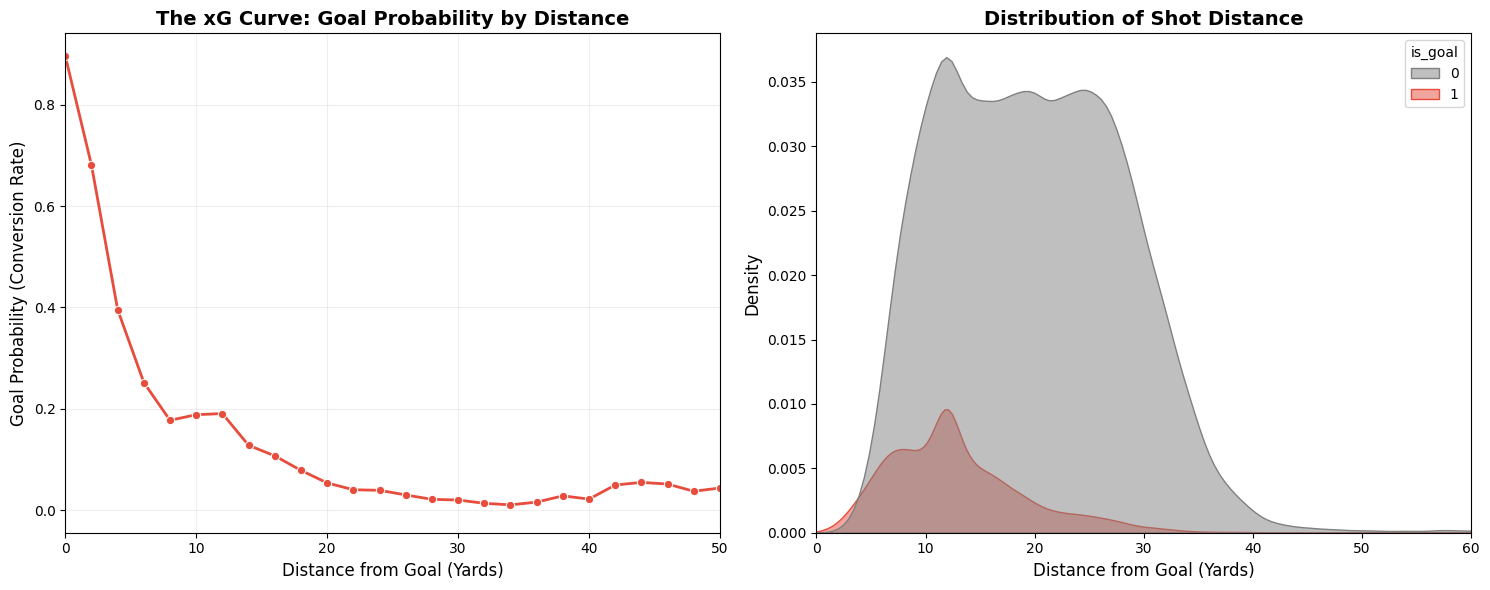

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Pearson Correlation Coefficient
correlation = df['distance'].corr(df['is_goal'])
print(f"📊 Correlation between Distance and is_goal: {correlation:.4f}")

# 2. Prepare data for the xG Curve (Binned Probability)
# Create 2-yard bins to smooth out the curve
df['dist_bin'] = (df['distance'] // 2) * 2
prob_curve = df.groupby('dist_bin')['is_goal'].mean()

# 3. Create Side-by-Side Plots
plt.figure(figsize=(15, 6))

# Plot A: The xG Curve (Probability vs Distance)
plt.subplot(1, 2, 1)
sns.lineplot(x=prob_curve.index, y=prob_curve.values, marker='o', color='#e74c3c', linewidth=2)
plt.title('The xG Curve: Goal Probability by Distance', fontsize=14, fontweight='bold')
plt.xlabel('Distance from Goal (Yards)', fontsize=12)
plt.ylabel('Goal Probability (Conversion Rate)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.xlim(0, 50) # Most shots happen within 50 yards

# Plot B: Distribution of Distance for Goals vs Misses
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='distance', hue='is_goal', fill=True, palette={0: 'grey', 1: '#e74c3c'}, alpha=0.5)
plt.title('Distribution of Shot Distance', fontsize=14, fontweight='bold')
plt.xlabel('Distance from Goal (Yards)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 60)

plt.tight_layout()
plt.show()

# 4. Cleanup temporary bin
df = df.drop(columns=['dist_bin'])

In [7]:
import numpy as np

# 1. Define the Angle Calculation Function
def calculate_angle(x, y):
    # Goal post coordinates (StatsBomb system)
    left_post = np.array([120, 36])
    right_post = np.array([120, 44])
    shot_point = np.array([x, y])

    # Vectors from ball to posts
    v1 = left_post - shot_point
    v2 = right_post - shot_point

    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    # Safety check for shots taken exactly on a post
    if norm_v1 == 0 or norm_v2 == 0:
        return 0

    # Calculate cosine of theta using dot product
    cos_theta = np.dot(v1, v2) / (norm_v1 * norm_v2)

    # Clip to avoid math errors from float precision, then convert to degrees
    angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    return np.degrees(angle_rad)

# 2. Apply the function
df['angle'] = df.apply(lambda row: calculate_angle(row['x'], row['y']), axis=1)

# 3. Reorder columns: Put 'angle' at index 3 (after distance)
cols = df.columns.tolist()
cols.remove('angle')
cols.insert(3, 'angle')
df = df[cols]

print("✅ 'angle' column created and placed next to 'distance'.")
display(df[['x', 'y', 'distance', 'angle', 'is_goal']].head())

# 4. Check the correlation
print(f"\n📊 Correlation between Angle and is_goal: {df['angle'].corr(df['is_goal']):.4f}")

✅ 'angle' column created and placed next to 'distance'.


,x,y,distance,angle,is_goal
0,100.4,35.1,20.203218,21.792845,0
1,114.6,33.5,8.450444,37.941499,0
2,106.2,55.8,20.978084,14.591831,0
3,113.9,47.4,9.590099,32.715019,0
4,89.2,42.5,30.901294,14.704957,0



📊 Correlation between Angle and is_goal: 0.3044


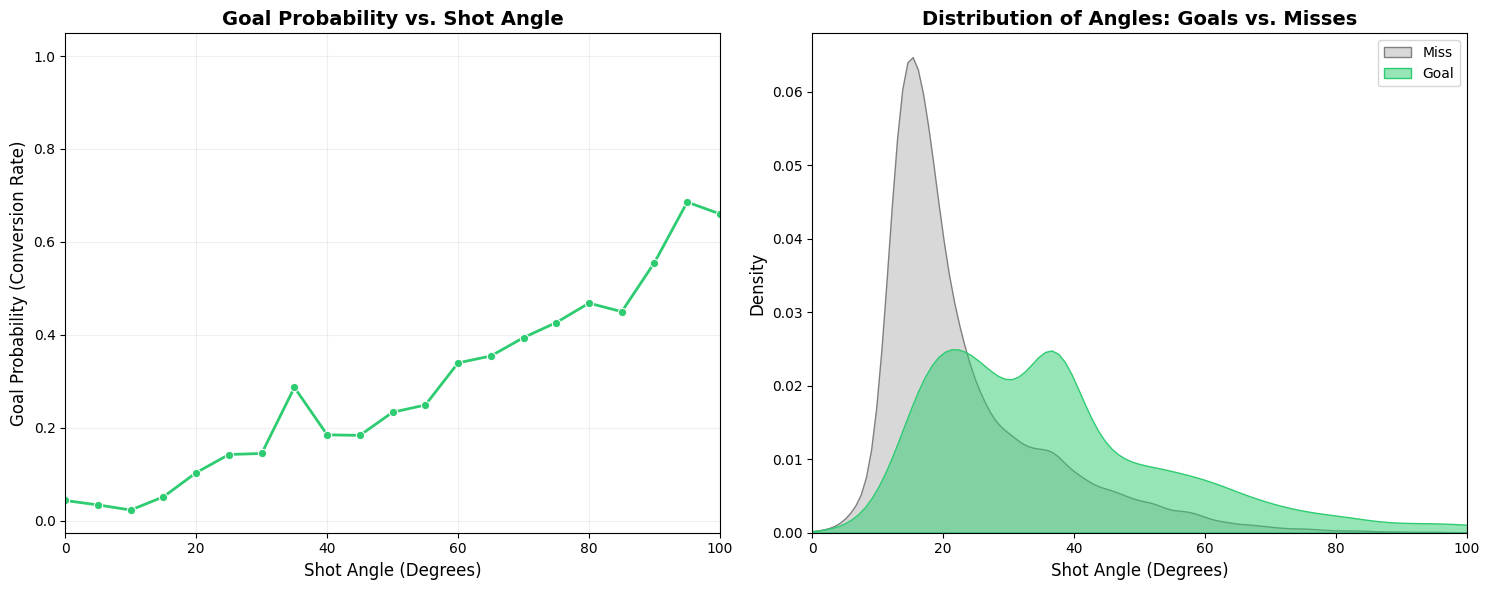

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create 5-degree bins for a smooth probability curve
df['angle_bin'] = (df['angle'] // 5) * 5
angle_prob = df.groupby('angle_bin')['is_goal'].mean()

# 2. Create Side-by-Side Plots
plt.figure(figsize=(15, 6))

# Plot A: The Angle-Goal Probability Curve
plt.subplot(1, 2, 1)
sns.lineplot(x=angle_prob.index, y=angle_prob.values, marker='o', color='#2ecc71', linewidth=2)
plt.title('Goal Probability vs. Shot Angle', fontsize=14, fontweight='bold')
plt.xlabel('Shot Angle (Degrees)', fontsize=12)
plt.ylabel('Goal Probability (Conversion Rate)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.xlim(0, 100)  # Most shots are within 0-90 degrees

# Plot B: Density Distribution (Goals vs Misses)
plt.subplot(1, 2, 2)
sns.kdeplot(data=df[df['is_goal'] == 0], x='angle', label='Miss', fill=True, color='grey', alpha=0.3)
sns.kdeplot(data=df[df['is_goal'] == 1], x='angle', label='Goal', fill=True, color='#2ecc71', alpha=0.5)
plt.title('Distribution of Angles: Goals vs. Misses', fontsize=14, fontweight='bold')
plt.xlabel('Shot Angle (Degrees)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

# 3. Clean up the temporary binning column
df = df.drop(columns=['angle_bin'])

In [9]:
df.head()

,x,y,distance,angle,is_goal,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,...,tech_Volley,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play
0,100.4,35.1,20.203218,21.792845,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,114.6,33.5,8.450444,37.941499,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,106.2,55.8,20.978084,14.591831,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,113.9,47.4,9.590099,32.715019,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,89.2,42.5,30.901294,14.704957,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [16]:
import numpy as np

# 1. Clean up old columns to prevent duplication errors
for col in ['angle', 'angle_bin', 'angle_deviation']:
    if col in df.columns:
        df = df.drop(columns=[col])

# 2. Define the Protractor Function (Goal-Centric Bearing)
def calculate_protractor_angle(x, y):
    dx = 120 - x  # Distance from goal line
    dy = y - 40   # Deviation from center (40)

    # arctan2(y, x) gives the angle in radians
    angle_rad = np.arctan2(dy, dx)
    angle_deg = np.degrees(angle_rad)

    # Map to 0-180 scale: 0 (Left), 90 (Center), 180 (Right)
    return 90 + angle_deg

# 3. Apply and Reorder
df['angle'] = df.apply(lambda row: calculate_protractor_angle(row['x'], row['y']), axis=1)
df['angle_deviation'] = np.abs(df['angle'] - 90)

# Reorder columns to place them: x, y, distance, angle, angle_deviation...
cols = df.columns.tolist()
for c in ['angle', 'angle_deviation']:
    cols.remove(c)

# Inserting right after 'distance' (which is at index 2)
cols.insert(3, 'angle')
cols.insert(4, 'angle_deviation')
df = df[cols]

print("✅ Features created: 'angle' (0-180) and 'angle_deviation' (side-by-side).")
display(df[['x', 'y', 'distance', 'angle', 'angle_deviation', 'is_goal']].head())

# 4. Check the Correlation
deviation_corr = df['angle_deviation'].corr(df['is_goal'])
print(f"\n📊 Correlation (Deviation from Center vs Goal): {deviation_corr:.4f}")

✅ Features created: 'angle' (0-180) and 'angle_deviation' (side-by-side).


,x,y,distance,angle,angle_deviation,is_goal
0,100.4,35.1,20.203218,75.963757,14.036243,0
1,114.6,33.5,8.450444,39.718759,50.281241,0
2,106.2,55.8,20.978084,138.865461,48.865461,0
3,113.9,47.4,9.590099,140.500411,50.500411,0
4,89.2,42.5,30.901294,94.640458,4.640458,0



📊 Correlation (Deviation from Center vs Goal): -0.0441


In [18]:
df.head()

,x,y,distance,angle,angle_deviation,is_goal,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,...,tech_Volley,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play
0,100.4,35.1,20.203218,75.963757,14.036243,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,114.6,33.5,8.450444,39.718759,50.281241,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,106.2,55.8,20.978084,138.865461,48.865461,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,113.9,47.4,9.590099,140.500411,50.500411,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,89.2,42.5,30.901294,94.640458,4.640458,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


/tmp/ipykernel_25984/1356710791.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('angle_bin').agg(
/tmp/ipykernel_25984/1356710791.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bin_stats, x='angle_bin', y='goals_scored', palette='Blues_d')
/tmp/ipykernel_25984/1356710791.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bin_stats, x='angle_bin', y='conversion_rate', palette='Reds_d')


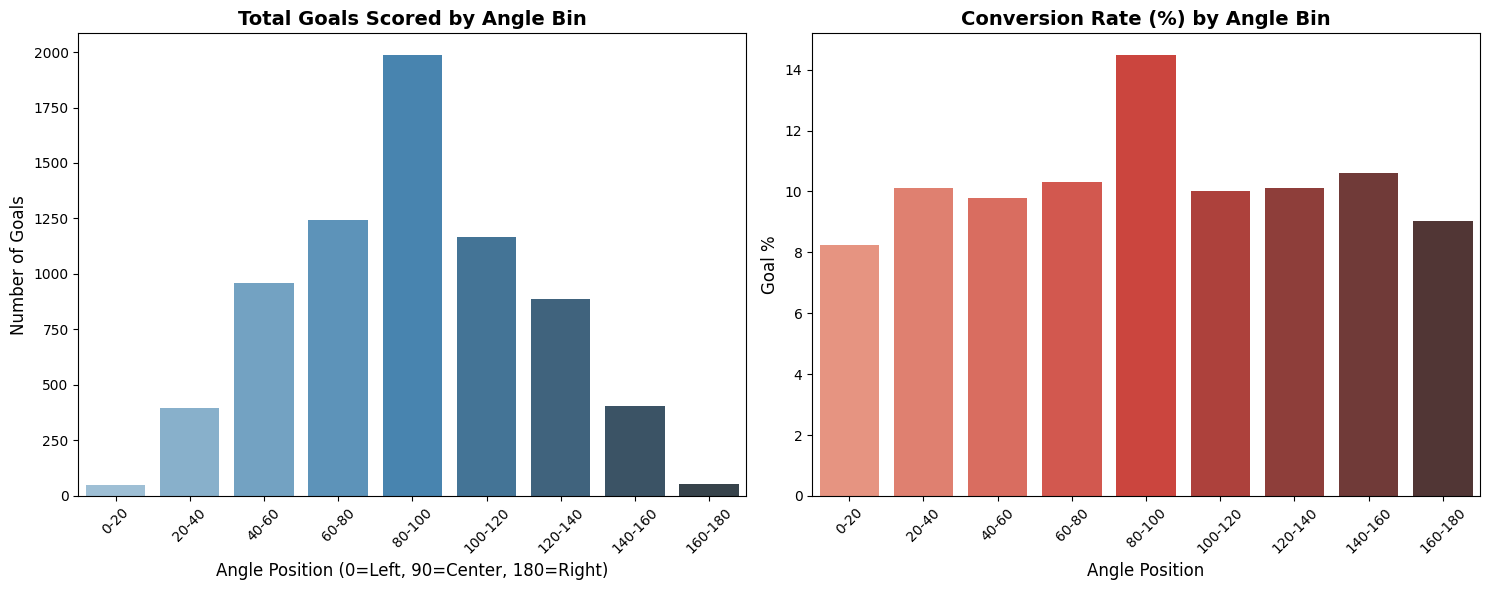

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Bins for the 0-180 Protractor scale
# Using 20-degree bins as you suggested
bins = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100', '100-120', '120-140', '140-160', '160-180']

# 2. Categorize the shots
df['angle_bin'] = pd.cut(df['angle'], bins=bins, labels=labels, include_lowest=True)

# 3. Calculate Stats: Total Shots and Goals per Bin
bin_stats = df.groupby('angle_bin').agg(
    total_shots=('is_goal', 'count'),
    goals_scored=('is_goal', 'sum')
).reset_index()

# 4. Calculate Conversion Rate (Efficiency)
bin_stats['conversion_rate'] = (bin_stats['goals_scored'] / bin_stats['total_shots']) * 100

# 5. Visualize
plt.figure(figsize=(15, 6))

# Plot A: Volume of Goals (Where do they happen?)
plt.subplot(1, 2, 1)
sns.barplot(data=bin_stats, x='angle_bin', y='goals_scored', palette='Blues_d')
plt.title('Total Goals Scored by Angle Bin', fontsize=14, fontweight='bold')
plt.xlabel('Angle Position (0=Left, 90=Center, 180=Right)', fontsize=12)
plt.ylabel('Number of Goals', fontsize=12)
plt.xticks(rotation=45)

# Plot B: Conversion Rate (Which angle is deadliest?)
plt.subplot(1, 2, 2)
sns.barplot(data=bin_stats, x='angle_bin', y='conversion_rate', palette='Reds_d')
plt.title('Conversion Rate (%) by Angle Bin', fontsize=14, fontweight='bold')
plt.xlabel('Angle Position', fontsize=12)
plt.ylabel('Goal %', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

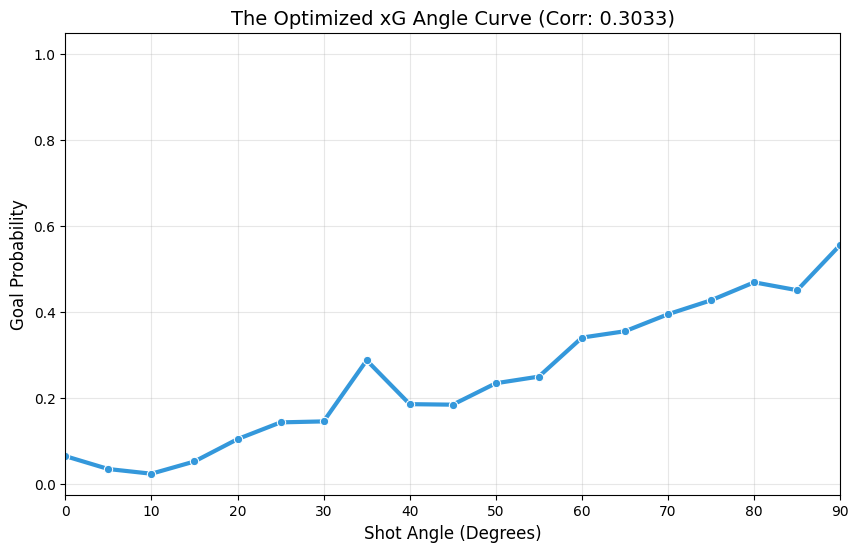

In [24]:
# Save the current state of the dataframe
df.to_csv('shots_final.csv', index=False)
print("✅ Dataset saved as 'shots_final.csv'")

✅ Dataset saved as 'shots_final.csv'
